In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\ML\ML-8 Decision Tree Resources 16936475981.txt")

In [3]:
data

,company,job,degree,salary_more_then_50000
0,Reliance,sales executive,bachelors,0
1,Reliance,sales executive,masters,0
2,Reliance,business manager,bachelors,1
3,Reliance,business manager,masters,1
4,Reliance,computer programmer,bachelors,0
5,Reliance,computer programmer,masters,1
6,Torrent,sales executive,masters,0
7,Torrent,computer programmer,bachelors,0
8,Torrent,business manager,bachelors,0
9,Torrent,business manager,masters,1


In [4]:
data.rename(columns={"salary_more_then_50000":"target"},inplace=True)

In [5]:
data.head()

,company,job,degree,target
0,Reliance,sales executive,bachelors,0
1,Reliance,sales executive,masters,0
2,Reliance,business manager,bachelors,1
3,Reliance,business manager,masters,1
4,Reliance,computer programmer,bachelors,0


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [8]:
# encoder.fit_transform(data["company"])

In [9]:
# encoder.inverse_transform([0,2,1])

In [10]:
x = data.drop("target",axis=1)
y = data["target"]

In [11]:
x

,company,job,degree
0,Reliance,sales executive,bachelors
1,Reliance,sales executive,masters
2,Reliance,business manager,bachelors
3,Reliance,business manager,masters
4,Reliance,computer programmer,bachelors
5,Reliance,computer programmer,masters
6,Torrent,sales executive,masters
7,Torrent,computer programmer,bachelors
8,Torrent,business manager,bachelors
9,Torrent,business manager,masters


In [12]:
x = x.apply(encoder.fit_transform)
x

,company,job,degree
0,0,2,0
1,0,2,1
2,0,0,0
3,0,0,1
4,0,1,0
5,0,1,1
6,2,2,1
7,2,1,0
8,2,0,0
9,2,0,1


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=50)

In [15]:
x_train

,company,job,degree
2,0,0,0
7,2,1,0
9,2,0,1
8,2,0,0
10,1,2,0
5,0,1,1
6,2,2,1
4,0,1,0
1,0,2,1
11,1,2,1


In [16]:
x_test

,company,job,degree
14,1,1,0
12,1,0,0
13,1,0,1
3,0,0,1


In [17]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
model = DecisionTreeClassifier()

In [19]:
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [20]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [21]:
model.score(x_train,y_train)

1.0

In [22]:
model.score(x_test,y_test)

1.0

In [23]:
ypri = model.predict(x_test)
ypri

array([1, 1, 1, 1])

In [24]:
y_test

14    1
12    1
13    1
3     1
Name: target, dtype: int64

In [25]:
accuracy_score(y_test,ypri)

1.0

In [26]:
c = confusion_matrix(y_test,ypri)
c

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


array([[4]])

In [27]:
import seaborn as sns

<Axes: >

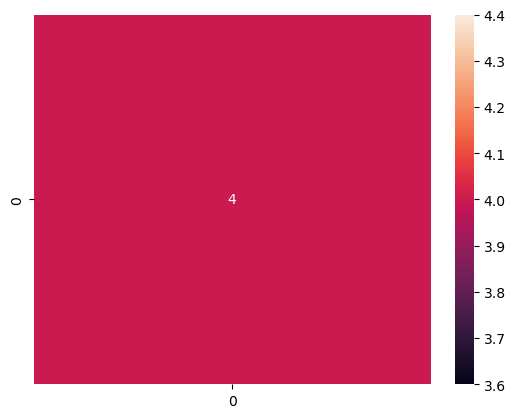

In [28]:
sns.heatmap(c,annot=True)

In [29]:
print(classification_report(y_test,ypri))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [30]:
from sklearn.tree import export_text

In [31]:
print(export_text(model))

|--- feature_0 <= 1.50
|   |--- feature_0 <= 0.50
|   |   |--- feature_1 <= 1.50
|   |   |   |--- feature_2 <= 0.50
|   |   |   |   |--- feature_1 <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_1 >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- feature_2 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_1 >  1.50
|   |   |   |--- class: 0
|   |--- feature_0 >  0.50
|   |   |--- class: 1
|--- feature_0 >  1.50
|   |--- feature_1 <= 0.50
|   |   |--- feature_2 <= 0.50
|   |   |   |--- class: 0
|   |   |--- feature_2 >  0.50
|   |   |   |--- class: 1
|   |--- feature_1 >  0.50
|   |   |--- class: 0



In [32]:
import matplotlib.pyplot as plt

In [33]:
from sklearn.tree import plot_tree

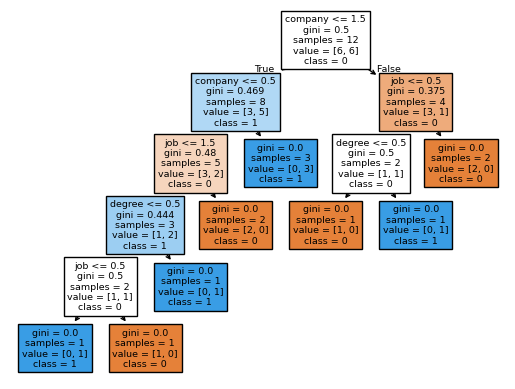

In [34]:
plot_tree(model,feature_names=x.columns,class_names=["0","1"],filled=True)
plt.show()